# SASRec 网格搜索（团队复现包）

数据：`SASRec/data/`；结果：`SASRec/results/grid_search/`。


In [ ]:
from pathlib import Path
import sys

def resolve_sasrec_dir() -> Path:
    cwd = Path.cwd().resolve()
    for c in (cwd, cwd.parent, cwd / "SASRec", cwd.parent / "SASRec"):
        if (c / "data").is_dir() and (c / "scripts").is_dir():
            return c
    raise FileNotFoundError("Cannot locate SASRec/ (need data/ and scripts/).")

SASREC_DIR = resolve_sasrec_dir()
REPO_ROOT = SASREC_DIR.parent  # optional: monorepo extras (e.g. ItemCF)
if str(SASREC_DIR) not in sys.path:
    sys.path.insert(0, str(SASREC_DIR))
assert (SASREC_DIR / "sasrec_core").is_dir(), "缺少 SASRec/sasrec_core/，请运行 scripts/sync_sasrec_core.py"

cache_dir = SASREC_DIR / "data"
results_dir = SASREC_DIR / "results" / "grid_search"
results_dir.mkdir(parents=True, exist_ok=True)
print("SASREC_DIR:", SASREC_DIR)
print("cache_dir:", cache_dir)


SASREC_DIR: E:\oytproject\UserBehavior_Analysis\SASRec
cache_dir: E:\oytproject\UserBehavior_Analysis\SASRec\data


In [ ]:
from __future__ import annotations

import itertools
import json
import time
from datetime import datetime
from pathlib import Path

import pandas as pd
import torch

from sasrec_core import (
    SASRecConfig,
    SASRecEstimator,
    build_memmap_cache,
    load_memmap_meta,
)


required = [
    cache_dir / 'train.parquet',
    cache_dir / 'valid.parquet',
    cache_dir / 'test.parquet',
    cache_dir / 'item2idx_mapping.parquet',
]
missing = [str(p) for p in required if not p.exists()]
if missing:
    raise FileNotFoundError(f'缺少数据文件: {missing}')

memmap_dir = build_memmap_cache(cache_dir=cache_dir, overwrite=False)
meta = load_memmap_meta(memmap_dir)
item_map_df = pd.read_parquet(cache_dir / 'item2idx_mapping.parquet', columns=['item_id', 'item_idx'])
idx2item = dict(zip(item_map_df['item_idx'].astype(int), item_map_df['item_id'].astype(int)))

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)
print('memmap_dir:', memmap_dir)
print('num_users:', meta['num_users'])
print('itemnum:', meta['itemnum'])


device: cuda
memmap_dir: E:\oytproject\UserBehavior_Analysis\SASRec\data\memmap_cache
num_users: 985877
itemnum: 1795765


用户数: 985877
最小长度: 1
最大长度: 818
均值: 93.9470877198677
中位数: 69.0

分位数:
0.500     69.0
0.800    146.0
0.900    205.0
0.950    263.0
0.990    387.0
0.995    438.0
0.999    544.0
Name: train_seq, dtype: float64

候选 maxlen 覆盖率:
   maxlen  users_len_ge_maxlen_ratio  users_clipped_ratio  \
0      50                   0.630043             0.622525   
1      80                   0.440077             0.434902   
2     100                   0.346825             0.342722   
3     120                   0.273422             0.270295   
4     160                   0.171676             0.169615   
5     200                   0.107183             0.105908   

   avg_effective_len_after_clip  
0                     41.553550  
1                     57.334174  
2                     65.119177  
3                     71.255549  
4                     79.940452  
5                     85.382661  


,maxlen,users_len_ge_maxlen_ratio,users_clipped_ratio,avg_effective_len_after_clip
0,50,0.630043,0.622525,41.553550
1,80,0.440077,0.434902,57.334174
2,100,0.346825,0.342722,65.119177
3,120,0.273422,0.270295,71.255549
4,160,0.171676,0.169615,79.940452
5,200,0.107183,0.105908,85.382661


e:\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 38271 (\N{CJK UNIFIED IDEOGRAPH-957F}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
e:\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
e:\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
e:\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
e:\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
e:\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 25130 (\N{CJK UNIFIED IDEOGRAPH-622A}) missing from f

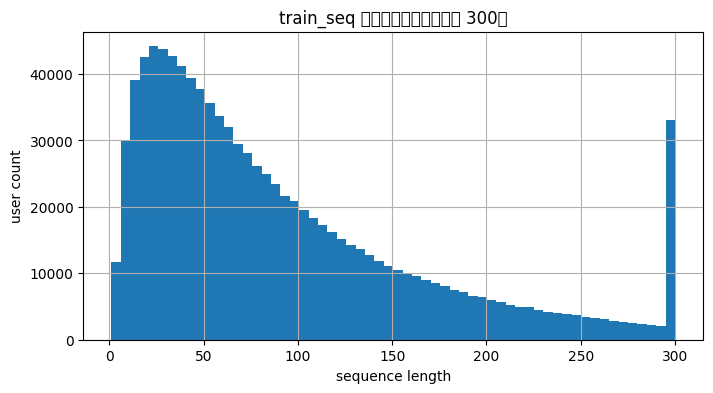

In [3]:
# 序列长度分布分析（用于确定 maxlen 搜索范围）
import ast
import numpy as np
import pandas as pd

train_df = pd.read_parquet(cache_dir / 'train.parquet', columns=['train_seq'])


def seq_len(x):
    if isinstance(x, list):
        return len(x)
    if isinstance(x, np.ndarray):
        return int(x.shape[0])
    if isinstance(x, str):
        v = ast.literal_eval(x)
        return len(v) if isinstance(v, list) else 1
    return len(list(x))


seq_lens = train_df['train_seq'].apply(seq_len).astype('int32')

print('用户数:', len(seq_lens))
print('最小长度:', int(seq_lens.min()))
print('最大长度:', int(seq_lens.max()))
print('均值:', float(seq_lens.mean()))
print('中位数:', float(seq_lens.median()))
print('\n分位数:')
print(seq_lens.quantile([0.5, 0.80, 0.9, 0.95, 0.99, 0.995, 0.999]))

candidates = [50, 80, 100, 120, 160, 200]
coverage_rows = []
for m in candidates:
    kept_ratio = float((seq_lens >= m).mean())
    clipped_ratio = float((seq_lens > m).mean())
    avg_kept = float(np.minimum(seq_lens, m).mean())
    coverage_rows.append({
        'maxlen': m,
        'users_len_ge_maxlen_ratio': kept_ratio,
        'users_clipped_ratio': clipped_ratio,
        'avg_effective_len_after_clip': avg_kept,
    })

coverage_df = pd.DataFrame(coverage_rows)
print('\n候选 maxlen 覆盖率:')
print(coverage_df)

# 可视化（长度分布，右长尾常见）
ax = seq_lens.clip(upper=300).hist(bins=60, figsize=(8, 4))
ax.set_title('train_seq 长度分布（截断显示到 300）')
ax.set_xlabel('sequence length')
ax.set_ylabel('user count')

coverage_df

## 阶段配置

### 阶段1：快速筛参（推荐先跑）
- `FAST_MODE = True`
- 评估用户数建议 `50k~100k`
- epoch 建议 `3~4`

### 阶段2：全量复核（只跑前几名）
- `FAST_MODE = False`
- `eval_user_limit = None`
- 只复核 Top-N 组合


In [4]:
# ========== 阶段开关 ==========
FAST_MODE = True

# 快速阶段参数（耗时更低）
fast_num_epochs = 3
fast_eval_user_limit = 100000

# 全量复核参数（耗时高）
full_num_epochs = 8
full_eval_user_limit = None

# 公共参数
eval_k = 10
seed = 42
num_workers = 0
weight_decay = 0.0

# 建议先控制在 8~16 组以内
grid_space = {
    'maxlen': [160], #[80, 100],
    'hidden_units': [128],
    'num_blocks': [4],
    'num_heads': [2],
    'dropout_rate': [0.15],
    'lr': [1e-3],
    'batch_size': [256 if device == 'cpu' else 512],
    'eval_num_neg': [100 if FAST_MODE else 200],
}

def build_experiments(space: dict) -> list[dict]:
    keys = list(space.keys())
    vals = [space[k] for k in keys]
    exps = []
    for one in itertools.product(*vals):
        row = dict(zip(keys, one))
        exps.append(row)
    return exps

experiments = build_experiments(grid_space)
print('FAST_MODE:', FAST_MODE)
print('实验组数:', len(experiments))
experiments[:3]


FAST_MODE: True
实验组数: 1


[{'maxlen': 160,
  'hidden_units': 128,
  'num_blocks': 4,
  'num_heads': 2,
  'dropout_rate': 0.15,
  'lr': 0.001,
  'batch_size': 512,
  'eval_num_neg': 100}]

In [5]:
def run_one_experiment(exp_id: int, hp: dict) -> dict:
    num_epochs = fast_num_epochs if FAST_MODE else full_num_epochs
    eval_user_limit = fast_eval_user_limit if FAST_MODE else full_eval_user_limit

    config = SASRecConfig(
        maxlen=int(hp['maxlen']),
        hidden_units=int(hp['hidden_units']),
        num_blocks=int(hp['num_blocks']),
        num_heads=int(hp['num_heads']),
        dropout_rate=float(hp['dropout_rate']),
        batch_size=int(hp['batch_size']),
        lr=float(hp['lr']),
        num_epochs=int(num_epochs),
        num_workers=int(num_workers),
        eval_num_neg=int(hp['eval_num_neg']),
        eval_k=int(eval_k),
        seed=int(seed),
        weight_decay=float(weight_decay),
    )

    est = SASRecEstimator(config=config, device=device)
    t0 = time.time()
    est.fit(
        input_mode='memmap',
        cache_dir=cache_dir,
        memmap_dir=memmap_dir,
        itemnum=int(meta['itemnum']),
        idx2item=idx2item,
        rebuild_memmap_cache=False,
        eval_user_limit=eval_user_limit,
        verbose=False,
    )
    fit_sec = time.time() - t0

    t1 = time.time()
    valid_metrics = est.evaluate(mode='valid', eval_user_limit=eval_user_limit)
    test_metrics = est.evaluate(mode='test', eval_user_limit=eval_user_limit)
    eval_sec = time.time() - t1

    last_loss = float(est.history[-1]['loss']) if est.history else None
    out = {
        'exp_id': exp_id,
        'mode': 'fast' if FAST_MODE else 'full',
        'fit_sec': fit_sec,
        'eval_sec': eval_sec,
        'last_loss': last_loss,
        'valid_hr10': float(valid_metrics.get('HR@10', 0.0)),
        'valid_ndcg10': float(valid_metrics.get('NDCG@10', 0.0)),
        'test_hr10': float(test_metrics.get('HR@10', 0.0)),
        'test_ndcg10': float(test_metrics.get('NDCG@10', 0.0)),
        'users_eval': float(valid_metrics.get('users', 0.0)),
        'num_epochs': num_epochs,
        'eval_user_limit': eval_user_limit,
        **hp,
    }
    return out


In [ ]:
run_tag = datetime.now().strftime('%Y%m%d_%H%M%S')
result_csv = results_dir / f'grid_search_{"fast" if FAST_MODE else "full"}_{run_tag}.csv'
result_jsonl = results_dir / f'grid_search_{"fast" if FAST_MODE else "full"}_{run_tag}.jsonl'

rows = []
for i, hp in enumerate(experiments, start=1):
    print(f'[{i}/{len(experiments)}] start =>', hp)
    one = run_one_experiment(i, hp)
    rows.append(one)
    pd.DataFrame(rows).sort_values(['valid_ndcg10', 'valid_hr10'], ascending=False).to_csv(result_csv, index=False)
    with result_jsonl.open('a', encoding='utf-8') as f:
        f.write(json.dumps(one, ensure_ascii=False) + '\n')
    print(
        f"[{i}/{len(experiments)}] done | "
        f"valid_hr10={one['valid_hr10']:.4f}, valid_ndcg10={one['valid_ndcg10']:.4f}, "
        f"fit={one['fit_sec']:.1f}s, eval={one['eval_sec']:.1f}s"
    )

print('结果已保存:')
print(' -', result_csv)
print(' -', result_jsonl)


[1/1] start => {'maxlen': 160, 'hidden_units': 128, 'num_blocks': 4, 'num_heads': 2, 'dropout_rate': 0.15, 'lr': 0.001, 'batch_size': 512, 'eval_num_neg': 100}


In [ ]:
import pandas as pd
csv_files = sorted(results_dir.glob('grid_search_fast_*.csv'))
if not csv_files:
    raise FileNotFoundError('No grid search csv in results/grid_search; run search first.')
df = pd.read_csv(csv_files[-1])
ranked = df.sort_values(['valid_ndcg10', 'valid_hr10'], ascending=False).reset_index(drop=True)
ranked.head(10)


## 阶段2使用说明（全量复核）

1. 从上面的 `ranked.head(10)` 里挑前 1~3 组参数。
2. 将 `FAST_MODE = False`。
3. 把 `grid_space` 改成仅包含要复核的那几组（避免全量耗时过大）。
4. 重新运行实验单元。

建议最终基线模型命名：

`baseline_sasrec_{YYYYMMDD_HHMMSS}_hr10_{HR10:.4f}_ndcg10_{NDCG10:.4f}.pt`


In [ ]:
# ====== 专项网格：hidden_units + num_blocks ======
# 目标：只搜索 hidden_units:[96,128] 与 num_blocks:[3,4]
# 其他参数先固定在当前较优配置

FAST_MODE = True  # 快筛阶段

grid_space = {
    "maxlen": [160],  # 可改成 [100,120,150]；先固定更省时
    "hidden_units": [96, 128],
    "num_blocks": [3, 4],
    "num_heads": [2],
    "dropout_rate": [0.15],
    "lr": [1e-3],
    "batch_size": [256 if device == "cpu" else 512],
    "eval_num_neg": [100 if FAST_MODE else 200],
}

experiments = build_experiments(grid_space)
print("实验组数:", len(experiments))
experiments

In [ ]:
# 锁定：maxlen=160，num_blocks=3
# 搜索：hidden_units=[96,128]
# 共 2 组

import itertools

FAST_MODE = True  # 你当前快筛阶段

def build_experiments(space: dict):
    keys = list(space.keys())
    vals = [space[k] for k in keys]
    return [dict(zip(keys, one)) for one in itertools.product(*vals)]

grid_space = {
    "maxlen": [160],
    "hidden_units": [128],
    "num_blocks": [3],
    "num_heads": [2],
    "dropout_rate": [0.15],
    "lr": [1e-3],
    "batch_size": [256 if device == "cpu" else 512],
    "eval_num_neg": [100 if FAST_MODE else 200],
}

experiments = build_experiments(grid_space)
print("实验组数:", len(experiments))
experiments